<a href="https://colab.research.google.com/github/OmarMohamedOmar1234/ATM-System/blob/main/Trusted%20%26%20Fake%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Project - Trusted vs Suspicious Detection



## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import cv2

from openpyxl import load_workbook

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv2D, MaxPooling2D, Flatten, Dropout


## 2. Load Data

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/DL_Project/Scraping data.xlsx"

# 3) reading file
data = pd.read_excel(file_path)

# 4) cleaning data
data = data.drop_duplicates().reset_index(drop=True)

# 5) show result
print("Data shape:", data.shape)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data shape: (671, 17)


,id,source,category,title,description,price,original_price,discount_percent,image_url,seller_name,seller_rating,seller_reviews_count,product_rating,reviews_count,reviews,location,image
0,1,amazon.eg,mobile,Apple iPhone 17 Pro Max (256 GB) - Cosmic Oran...,UNIBODY DESIGN. FOR EXCEPTIONAL POWER.—Heat-fo...,98777..00,98777..00,0,https://m.media-amazon.com/images/I/61yXZ6sG6G...,Brand: Apple,3.8,40,3.8,0,"[""ممتاز. تجاوز التوقعات."", ""التليفون لا يعمل و...",Egypt,NaN
1,2,amazon.eg,mobile,Apple iPhone 16 (128 GB) - White with Face ID ...,6.1-inch Super Retina XDR display with Dynamic...,65000..00,65000..00,0,https://m.media-amazon.com/images/I/61+eDlSTiq...,Brand: Apple,4.6,2376,4.6,1,"[""Overall experience of the mobile phone is go...",Egypt,NaN
2,3,amazon.eg,mobile,Apple iPhone 16 Pro (128 GB) - Desert Titanium,STUNNING TITANIUM DESIGN—iPhone 16 Pro has a s...,83212..00,83212..00,0,https://m.media-amazon.com/images/I/617ZhMUCvI...,Brand: Apple,4.4,39,4.4,1,"[""The best I phone..... It's really amazing.. ...",Egypt,NaN
3,4,amazon.eg,mobile,Apple iPhone 16 Plus (128 GB) - Blue with Face...,Expansive 6.7-inch Super Retina XDR display wi...,NaN,NaN,0,https://m.media-amazon.com/images/I/71oWrfCTiq...,Brand: Apple,4.6,654,4.6,0,"[""من فضل حضرتك عايزه الفاتوره الضريبية"", ""Lief...",Egypt,NaN
4,5,amazon.eg,mobile,Apple iPhone 17 Pro (256 GB) - Deep Blue with ...,UNIBODY DESIGN. FOR EXCEPTIONAL POWER. — Heat-...,97500..00,97500..00,0,https://m.media-amazon.com/images/I/615szeYqyU...,Brand: Apple,4.1,43,4.1,0,"[""المنتج غير هو صحيح كوبي كوبي""]",Egypt,NaN


## 3. Preprocessing (Afnan)

In [ ]:
# convert numeric columns
numeric_cols = [
    'seller_rating',
    'product_rating',
    'seller_reviews_count',
    'discount_percent',
    'price',
    'original_price'
]

for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# fill discount if missing
data['discount_percent'] = data['discount_percent'].fillna(0)

# remove rows missing important numerical features
data = data.dropna(subset=[
    'seller_rating',
    'seller_reviews_count',
    'product_rating'
]).reset_index(drop=True)

print("Data shape after cleaning:", data.shape)


Data shape after cleaning: (530, 17)


## 4. Text Cleaning

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['title'] = data['title'].apply(clean_text)
data['description'] = data['description'].apply(clean_text)

if 'reviews' not in data.columns:
    data['reviews'] = ""

data['reviews'] = data['reviews'].fillna("").apply(clean_text)

print(data[['title', 'description', 'reviews']].head())


                                               title  \
0  apple iphone pro max gb cosmic orange with fac...   
1  apple iphone gb white with face id tax paid ye...   
2                apple iphone pro gb desert titanium   
3  apple iphone plus gb blue with face id tax pai...   
4  apple iphone pro gb deep blue with face id tax...   

                                         description  \
0  unibody design for exceptional power heat forg...   
1  inch super retina xdr display with dynamic isl...   
2  stunning titanium design iphone pro has a stro...   
3  expansive inch super retina xdr display with d...   
4  unibody design for exceptional power heat forg...   

                                             reviews  
0  ممتاز تجاوز التوقعات التليفون لا يعمل ودخل فى ...  
1  overall experience of the mobile phone is good...  
2  the best i phone it s really amazing specialy ...  
3  من فضل حضرتك عايزه الفاتوره الضريبية lieferzei...  
4                       المنتج غير هو صحيح كوبي كوب

## 5. Remove Extreme Values

In [ ]:
for col in ['seller_rating', 'product_rating', 'seller_reviews_count']:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data = data[(data[col] >= lower) & (data[col] <= upper)]

data = data.reset_index(drop=True)
print("Data shape after removing outliers:", data.shape)


Data shape after removing outliers: (524, 17)


## 6. Feature Engineering

In [ ]:
# price features
data['price_diff'] = data['original_price'] - data['price']
data['real_discount'] = (data['price_diff'] / data['original_price']) * 100
data['real_discount'] = data['real_discount'].replace([np.inf, -np.inf], np.nan).fillna(0)

# review features
data['review_len'] = data['reviews'].apply(lambda x: len(x.split()))

suspicious_words = ['fake', 'bad', 'poor', 'worst', 'scam', 'مش', 'سيء', 'وحش']

def count_suspicious(text):
    return sum(word in text for word in suspicious_words)

data['suspicious_score'] = data['reviews'].apply(count_suspicious)

# verified column
if 'is_verified' in data.columns:
    data['is_verified'] = data['is_verified'].apply(lambda x: 1 if x == True else 0)
else:
    data['is_verified'] = 0

data[['seller_rating','product_rating','seller_reviews_count','real_discount','suspicious_score']].head()


,seller_rating,product_rating,seller_reviews_count,real_discount,suspicious_score
0,3.8,3.8,40,0.0,1
1,4.6,4.6,2376,0.0,0
2,4.4,4.4,39,0.0,0
3,4.6,4.6,654,0.0,0
4,4.1,4.1,43,0.0,0


## 7. Labeling (Gana)

In [ ]:
low_seller_rating = data['seller_rating'].quantile(0.25)
low_product_rating = data['product_rating'].quantile(0.25)
low_seller_reviews_count = data['seller_reviews_count'].quantile(0.50)

non_zero_discount = data[data['real_discount'] > 0]['real_discount']
if len(non_zero_discount) > 0:
    high_discount = non_zero_discount.quantile(0.75)
else:
    high_discount = data['real_discount'].quantile(0.75)

print("Thresholds used:")
print("Low seller rating:", low_seller_rating)
print("Low product rating:", low_product_rating)
print("Low seller reviews count:", low_seller_reviews_count)
print("High discount:", high_discount)

def create_label(row):
    score = 0

    if row['seller_rating'] < low_seller_rating:
        score += 1

    if row['product_rating'] < low_product_rating:
        score += 1

    if row['seller_reviews_count'] < low_seller_reviews_count:
        score += 1

    if row['real_discount'] > high_discount:
        score += 1

    if row['suspicious_score'] > 0:
        score += 1

    # 1 = Suspicious, 0 = Trusted
    return 1 if score >= 2 else 0

data['label'] = data.apply(create_label, axis=1)

print(data['label'].value_counts())


Thresholds used:
Low seller rating: 3.9
Low product rating: 3.9
Low seller reviews count: 51.5
High discount: 0.0
label
0    386
1    138
Name: count, dtype: int64


In [ ]:
data.to_excel("labeled_data.xlsx", index=True)
print("Excel file saved with index column")

Excel file saved with index column


## 8. Extract Images From Excel

In [ ]:
from google.colab import drive
import os
import imghdr
from openpyxl import load_workbook

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/DL_Project/Scraping data.xlsx"

wb = load_workbook(file_path)
ws = wb.active

os.makedirs("images", exist_ok=True)

image_paths = []

for i, img_obj in enumerate(ws._images):
    img_data = img_obj._data()


    img_type = imghdr.what(None, h=img_data)
    ext = img_type if img_type else "png"

    path = f"images/img_{i}.{ext}"
    with open(path, "wb") as f:
        f.write(img_data)

    image_paths.append(path)


print("number of photoes", len(image_paths))
print("number of rows", len(data))

min_len = min(len(image_paths), len(data))
data = data.iloc[:min_len].copy().reset_index(drop=True)
data['image_path'] = image_paths[:min_len]

print("Final data shape:", data.shape)

/tmp/ipykernel_16553/2291086322.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr  # ← الإضافة الجديدة


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
عدد الصور: 672
عدد الصفوف: 524
Final data shape: (524, 24)


## 9. Prepare Text Data

In [ ]:
data['combined_text'] = (
    data['title'].fillna('').astype(str) + ' ' +
    data['description'].fillna('').astype(str) + ' ' +
    data['reviews'].fillna('').astype(str)
)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(data['combined_text'])

sequences = tokenizer.texts_to_sequences(data['combined_text'])
X_text = pad_sequences(sequences, maxlen=100)

print("X_text shape:", X_text.shape)


X_text shape: (524, 100)


## 10. Prepare Image Data

In [ ]:
def load_image(path):
    img = cv2.imread(path)

    if img is None:
        try:
            import matplotlib.image as mpimg
            img = mpimg.imread(path)
            if img is not None:
                img = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR) \
                      if img.max() <= 1.0 else cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        except:
            return None

    if img is None:
        return None

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    return img

valid_images = []
valid_indexes = []

for idx, path in enumerate(data['image_path']):
    img = load_image(path)
    if img is not None:
        valid_images.append(img)
        valid_indexes.append(idx)

X_images = np.array(valid_images)
data = data.iloc[valid_indexes].reset_index(drop=True)
X_text = X_text[valid_indexes]

data['label'] = data.apply(create_label, axis=1)

y = data['label'].astype(int).values

print("X_text:", X_text.shape)
print("X_images:", X_images.shape)
print("y:", y.shape)
print(data['label'].value_counts())


X_text: (524, 100)
X_images: (524, 224, 224, 3)
y: (524,)
label
0    386
1    138
Name: count, dtype: int64


## 11. Train/Test Split

In [ ]:
indices = np.arange(len(data))

X_text_train, X_text_test, X_img_train, X_img_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text,
    X_images,
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_text_train.shape, X_text_test.shape)
print(X_img_train.shape, X_img_test.shape)
print(y_train.shape, y_test.shape)


(419, 100) (105, 100)
(419, 224, 224, 3) (105, 224, 224, 3)
(419,) (105,)


##12.Text Models: LSTM vs Transformer  (**Loay**)

### Architecture Justification

**LSTM — chosen for sequential pattern detection:**
- Input: padded sequences of max 100 tokens
- Embedding dim = 64 (balances vocab size 10,000 with model capacity)
- Hidden units = 32 (prevents overfitting on small dataset)
- Single layer to avoid vanishing gradient on short texts

**Transformer — chosen for global context modeling:**
- num_heads = 2 (sufficient for binary classification)
- key_dim = 32 (matches embedding size)
- GlobalAveragePooling instead of CLS token (simpler, works well on short texts)

**Why both?**
- LSTM captures local sequential patterns (word order matters)
- Transformer captures global dependencies (any word can attend to any other)
- Best model selected automatically based on validation accuracy

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

# --- Model 1: LSTM ---
model_text = Sequential([
    Embedding(10000, 64),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model_text.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_text = model_text.fit(
    X_text_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_text_test, y_test)
)

text_pred = (model_text.predict(X_text_test) > 0.5).astype(int).ravel()
lstm_acc = accuracy_score(y_test, text_pred)
print("LSTM Accuracy:", lstm_acc)


# --- Model 2: Transformer ---
inputs = tf.keras.Input(shape=(100,))
x = Embedding(10000, 64)(inputs)
x = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model_text_transformer = tf.keras.Model(inputs, outputs)

model_text_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transformer = model_text_transformer.fit(
    X_text_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_text_test, y_test)
)

transformer_pred = (model_text_transformer.predict(X_text_test) > 0.5).astype(int).ravel()
transformer_acc = accuracy_score(y_test, transformer_pred)
print("Transformer Accuracy:", transformer_acc)


# --- Comparison ---
print("\n=== Text Model Comparison ===")
print("LSTM Accuracy:        " + str(round(lstm_acc, 4)))
print("Transformer Accuracy: " + str(round(transformer_acc, 4)))

if transformer_acc > lstm_acc:
    print("Transformer ahsan - hanstakhdemoh fel Fusion")
    best_text_pred = transformer_pred
else:
    print("LSTM ahsan - hanstakhdemoh fel Fusion")
    best_text_pred = text_pred

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.7160 - loss: 0.6721 - val_accuracy: 0.7333 - val_loss: 0.6372
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7375 - loss: 0.5541 - val_accuracy: 0.7333 - val_loss: 0.5464
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7518 - loss: 0.4280 - val_accuracy: 0.7524 - val_loss: 0.5304
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8735 - loss: 0.2755 - val_accuracy: 0.7238 - val_loss: 0.4996
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9785 - loss: 0.1500 - val_accuracy: 0.7333 - val_loss: 0.6920
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
LSTM Accuracy: 0.7333333333333333
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 379ms/step - accuracy: 0.7255 - loss: 0.6035 - val_accuracy: 0.7333 - val_loss: 0.5768
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7399 - loss: 0.5001 - val_accuracy: 0.7810 - val_loss: 0.5075
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms

#### 13.Image Models: EfficientNet vs Simple CNN (**Omar**)

### Architecture Justification

**EfficientNetB0 — Transfer Learning:**
- Pre-trained on ImageNet (1.28M images, 1000 classes)
- Frozen base = preserves learned features (edges, textures, shapes)
- Added GlobalAveragePooling2D → Dense(64) → Dropout(0.3) → sigmoid
- Dropout = 0.3 chosen to regularize without underfitting

**Simple CNN — Baseline:**
- 2 Conv layers (32→64 filters) trained from scratch
- Used only to prove Transfer Learning superiority
- Expected to underperform due to small dataset size

**Conclusion:**
EfficientNet leverages pretrained knowledge → higher accuracy with fewer epochs
Simple CNN trains from zero → weaker on small datasets
```



In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# --- Pretrained EfficientNetB0 ---
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze pretrained weights

model_image = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_image.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_image = model_image.fit(
    X_img_train,
    y_train,
    epochs=6,
    batch_size=16,
    validation_data=(X_img_test, y_test)
)

image_pred = (model_image.predict(X_img_test) > 0.5).astype(int).ravel()
image_acc = accuracy_score(y_test, image_pred)
print("EfficientNet (Pretrained) Image Model Accuracy:", image_acc)


# --- Compare with Simple CNN ---
model_cnn_simple = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_cnn_simple.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn_simple.fit(
    X_img_train,
    y_train,
    epochs=6,
    batch_size=16,
    validation_data=(X_img_test, y_test)
)

cnn_simple_pred = (model_cnn_simple.predict(X_img_test) > 0.5).astype(int).ravel()
cnn_simple_acc = accuracy_score(y_test, cnn_simple_pred)

print("\n=== Image Model Comparison ===")
print(f"Simple CNN Accuracy:          {cnn_simple_acc:.4f}")
print(f"EfficientNet (Pretrained):    {image_acc:.4f}")
print(" ImageNet EfficientNet is better because it is pretrained on ImageNet and benefits from Transfer Learning.")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7232 - loss: 0.6314 - val_accuracy: 0.7333 - val_loss: 0.5818
Epoch 2/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7375 - loss: 0.5895 - val_accuracy: 0.7333 - val_loss: 0.5866
Epoch 3/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7375 - loss: 0.5857 - val_accuracy: 0.7333 - val_loss: 0.5828
Epoch 4/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7375 - loss: 0.6000 - val_accuracy: 0.7333 - val_loss: 0.5799
Epoch 5/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7375 - loss: 0.5806 - val_accuracy: 0.7333 - val_loss: 0.5802
Epoch 6/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7375 - loss: 0.5815 - val_accuracy: 0.7333 - val_loss: 0.5798


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


EfficientNet (Pretrained) Image Model Accuracy: 0.7333333333333333
Epoch 1/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.6706 - loss: 1.2726 - val_accuracy: 0.7333 - val_loss: 0.5911
Epoch 2/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7375 - loss: 0.6070 - val_accuracy: 0.7333 - val_loss: 0.6140
Epoch 3/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7327 - loss: 0.5597 - val_accuracy: 0.7333 - val_loss: 0.6386
Epoch 4/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7637 - loss: 0.5028 - val_accuracy: 0.7143 - val_loss: 0.6616
Epoch 5/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7900 - loss: 0.4462 - val_accuracy: 0.7048 - val_loss: 0.6685
Epoch 6/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8186 - loss: 0.3750 - val_accuracy: 0.6952 - val_loss: 0.7364
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step

=== Image Model Comparison ===
Simple CNN Accuracy:          0.6952
EfficientNet (Pretrained):    0.7333
✅ EfficientNet أحسن لأنه pretr

## 14. Seller Model (تكملة أفنان)


### Why Random Forest?
- Seller data is tabular (numbers not text or images)
- Random Forest handles numerical features very well
- Robust to noise and outliers in the data

### Features Used:
- Seller Rating → low rating = suspicious
- Seller Reviews Count → very few reviews = untrusted
- Product Rating → low product rating = suspicious
- Real Discount → unrealistic discount = red flag

### Why Not a Deep Learning Model?
- Tabular data does not need complex neural networks
- Random Forest gives high accuracy with less training time
- Simple, explainable, and reliable for structured data

In [ ]:
seller_features = [
    'seller_rating',
    'seller_reviews_count',
    'product_rating',
    'real_discount'
]

X_seller = data[seller_features]
y_seller = data['label'].astype(int)

X_seller_train, X_seller_test, y_seller_train, y_seller_test = train_test_split(
    X_seller,
    y_seller,
    test_size=0.2,
    random_state=42,
    stratify=y_seller
)

model_seller = RandomForestClassifier(n_estimators=50, random_state=42)
model_seller.fit(X_seller_train, y_seller_train)

seller_pred = model_seller.predict(X_seller_test)
print("Seller Model Accuracy:", accuracy_score(y_seller_test, seller_pred))


Seller Model Accuracy: 0.9523809523809523


## 15. Review Model (تكملة جنى)


## Cell 15 — Review Model: Naive Bayes

### Why Naive Bayes?
- Review text needs a fast and simple text classifier
- Naive Bayes is specifically designed for text classification
- Works very well even with small amounts of text data

### Features Used:
- Review text converted to word counts using CountVectorizer
- Top 500 most important words selected as features
- Suspicious words like "fake", "scam", "bad", "وحش", "سيء" are strong signals

### Why Not LSTM or Transformer?
- Reviews are already analyzed by the Text Model in Cell 12
- Naive Bayes adds a different perspective using word frequency only
- Using different model types makes the Fusion stronger and more diverse

In [ ]:
review_vectorizer = CountVectorizer(max_features=500)

X_review = review_vectorizer.fit_transform(data['reviews'].fillna('').astype(str))
y_review = data['label'].astype(int)

X_review_train, X_review_test, y_review_train, y_review_test = train_test_split(
    X_review,
    y_review,
    test_size=0.2,
    random_state=42,
    stratify=y_review
)

model_review = MultinomialNB()
model_review.fit(X_review_train, y_review_train)

review_pred = model_review.predict(X_review_test)
print("Review Model Accuracy:", accuracy_score(y_review_test, review_pred))


Review Model Accuracy: 0.6857142857142857


## 16. Price Model

### Why Random Forest?
- Price data is tabular (numbers only)
- Random Forest detects unusual pricing patterns very effectively
- Handles multiple price features together with high accuracy

### Features Used:
- Price → actual selling price
- Original Price → price before discount
- Discount Percent → stated discount percentage
- Real Discount → calculated actual discount
- Price Diff → difference between original and selling price

### Why Price is Important?
- Unrealistically low prices are a strong fraud signal
- Example: "iPhone 14 for 500 EGP" → obvious red flag
- Huge discounts with no reason = suspicious product

### Why Not a Deep Learning Model?
- Price features are pure numbers, no need for neural networks
- Random Forest handles numerical patterns faster and more accurately
- Simple, reliable, and easy to interpret

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

price_features = [
    'price',
    'original_price',
    'discount_percent',
    'real_discount',
    'price_diff'
]

X_price = data[price_features]
y_price = data['label'].astype(int)

X_price_train, X_price_test, y_price_train, y_price_test = train_test_split(
    X_price,
    y_price,
    test_size=0.2,
    random_state=42,
    stratify=y_price
)

model_price = RandomForestClassifier(n_estimators=50, random_state=42)
model_price.fit(X_price_train, y_price_train)

price_pred = model_price.predict(X_price_test)

print("Price Model Accuracy:", accuracy_score(y_price_test, price_pred))

Price Model Accuracy: 0.7523809523809524


## 17. Fusion + Explainability

In [ ]:
## 17. Fusion + Explainability

# ============================================================
# Prediction Functions
# ============================================================

def predict_text(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    lstm_score = float(model_text.predict(padded, verbose=0)[0][0])
    transformer_score = float(model_text_transformer.predict(padded, verbose=0)[0][0])
    return (lstm_score + transformer_score) / 2

def predict_image(img_path):
    img = load_image(img_path)
    if img is None:
        return 0.5
    img = np.expand_dims(img, axis=0)
    return float(model_image.predict(img, verbose=0)[0][0])

def predict_seller(seller_rating, seller_reviews_count, product_rating, real_discount):
    sample = pd.DataFrame([{
        'seller_rating': seller_rating,
        'seller_reviews_count': seller_reviews_count,
        'product_rating': product_rating,
        'real_discount': real_discount
    }])
    return float(model_seller.predict_proba(sample)[0][1])

def predict_review(review):
    review = clean_text(review)
    x = review_vectorizer.transform([review])
    return float(model_review.predict_proba(x)[0][1])

def predict_price(price, original_price, discount_percent, real_discount, price_diff):
    sample = pd.DataFrame([{
        'price': price,
        'original_price': original_price,
        'discount_percent': discount_percent,
        'real_discount': real_discount,
        'price_diff': price_diff
    }])
    return float(model_price.predict_proba(sample)[0][1])

def explain_result(text_score, image_score, seller_score, review_score, price_score):
    reasons = []
    if text_score > 0.5:
        reasons.append("Text contains suspicious indicators")
    if image_score > 0.5:
        reasons.append("Image appears suspicious or low quality")
    if seller_score > 0.5:
        reasons.append("Seller data is weak or unreliable")
    if review_score > 0.5:
        reasons.append("Reviews contain abnormal or fake patterns")
    if price_score > 0.5:
        reasons.append("Price or discount is unrealistic")
    if len(reasons) == 0:
        reasons.append("All data looks normal and trusted")
    return reasons

def final_prediction(text, img_path,
                     seller_rating, seller_reviews_count,
                     product_rating, real_discount,
                     review, price, original_price,
                     discount_percent, price_diff):

    text_score   = predict_text(text)
    image_score  = predict_image(img_path)
    seller_score = predict_seller(seller_rating, seller_reviews_count, product_rating, real_discount)
    review_score = predict_review(review)
    price_score  = predict_price(price, original_price, discount_percent, real_discount, price_diff)

    final_score = (
        text_score   * 0.20 +
        image_score  * 0.10 +
        seller_score * 0.30 +
        review_score * 0.15 +
        price_score  * 0.25
    )

    label = "Suspicious" if final_score > 0.5 else "Trusted"
    reasons = explain_result(text_score, image_score, seller_score, review_score, price_score)

    return label, final_score, reasons

# ============================================================
# Step 1: Run Fixed Weights Fusion
# ============================================================
fusion_preds = []

for i in idx_test:
    sample = data.iloc[i]
    label, score, _ = final_prediction(
        text=sample['combined_text'],
        img_path=sample['image_path'],
        seller_rating=sample['seller_rating'],
        seller_reviews_count=sample['seller_reviews_count'],
        product_rating=sample['product_rating'],
        real_discount=sample['real_discount'],
        review=sample['reviews'],
        price=sample['price'],
        original_price=sample['original_price'],
        discount_percent=sample['discount_percent'],
        price_diff=sample['price_diff']
    )
    fusion_preds.append(1 if label == "Suspicious" else 0)

print("Fixed Weights Fusion Accuracy:", accuracy_score(y_test, fusion_preds))

# ============================================================
# Step 2: Dynamic Confidence-Based Fusion
# ============================================================
def dynamic_fusion(idx_test, data):
    """
    Instead of fixed weights, uses each model's own confidence (distance from 0.5)
    Higher confidence = higher weight automatically
    """
    preds = []
    for i in idx_test:
        sample = data.iloc[i]

        scores = {
            'text':   predict_text(sample['combined_text']),
            'image':  predict_image(sample['image_path']),
            'seller': predict_seller(sample['seller_rating'], sample['seller_reviews_count'],
                                     sample['product_rating'], sample['real_discount']),
            'review': predict_review(sample['reviews']),
            'price':  predict_price(sample['price'], sample['original_price'],
                                    sample['discount_percent'], sample['real_discount'],
                                    sample['price_diff'])
        }

        confidences = {k: abs(v - 0.5) for k, v in scores.items()}
        total_conf = sum(confidences.values()) or 1
        final = sum(scores[k] * confidences[k] / total_conf for k in scores)
        preds.append(1 if final > 0.5 else 0)

    return preds

dynamic_preds = dynamic_fusion(idx_test, data)
dynamic_acc = accuracy_score(y_test, dynamic_preds)

print(f"Fixed Weights Fusion Accuracy:   {accuracy_score(y_test, fusion_preds):.4f}")
print(f"Dynamic Confidence Fusion Acc:   {dynamic_acc:.4f}")
print("Dynamic Fusion adapts weights based on each model's confidence per sample")

# ============================================================
# Step 3: Results Summary
# ============================================================
text_acc   = accuracy_score(y_test, text_pred)
image_acc  = accuracy_score(y_test, image_pred)
seller_acc = accuracy_score(y_seller_test, seller_pred)
review_acc = accuracy_score(y_review_test, review_pred)
price_acc  = accuracy_score(y_price_test, price_pred)

results = pd.DataFrame({
    "Model":    ["Text LSTM", "Image CNN", "Seller RF", "Review NB", "Price RF", "Fusion"],
    "Accuracy": [text_acc, image_acc, seller_acc, review_acc, price_acc,
                 accuracy_score(y_test, fusion_preds)]
})

print(results)

Fusion Accuracy: 0.9238095238095239


In [ ]:
text_acc = accuracy_score(y_test, text_pred)
image_acc = accuracy_score(y_test, image_pred)
seller_acc = accuracy_score(y_seller_test, seller_pred)
review_acc = accuracy_score(y_review_test, review_pred)
price_acc = accuracy_score(y_price_test, price_pred)

results = pd.DataFrame({
    "Model": ["Text LSTM", "Image CNN", "Seller RF", "Review NB", "Price RF", "Fusion"],
    "Accuracy": [text_acc, image_acc, seller_acc, review_acc, price_acc, accuracy_score(y_test, fusion_preds)]
})

print(results)

       Model  Accuracy
0  Text LSTM  0.733333
1  Image CNN  0.733333
2  Seller RF  0.952381
3  Review NB  0.685714
4   Price RF  0.752381
5     Fusion  0.923810


In [ ]:
## 17b. Ablation Study — Fusion Weights Analysis

print("=" * 60)
print("ABLATION STUDY — Effect of Removing Each Model from Fusion")
print("=" * 60)

def fusion_with_weights(idx_test, data, w_text, w_image, w_seller, w_review, w_price):
    preds = []
    for i in idx_test:
        sample = data.iloc[i]
        text_score   = predict_text(sample['combined_text'])
        image_score  = predict_image(sample['image_path'])
        seller_score = predict_seller(sample['seller_rating'], sample['seller_reviews_count'],
                                      sample['product_rating'], sample['real_discount'])
        review_score = predict_review(sample['reviews'])
        price_score  = predict_price(sample['price'], sample['original_price'],
                                     sample['discount_percent'], sample['real_discount'],
                                     sample['price_diff'])

        total_w = w_text + w_image + w_seller + w_review + w_price
        score = (text_score*w_text + image_score*w_image + seller_score*w_seller +
                 review_score*w_review + price_score*w_price) / total_w

        preds.append(1 if score > 0.5 else 0)
    return preds

ablation_configs = {
    "Full Fusion (baseline)": (0.20, 0.10, 0.30, 0.15, 0.25),
    "No Text Model":          (0,    0.10, 0.30, 0.15, 0.25),
    "No Image Model":         (0.20, 0,    0.30, 0.15, 0.25),
    "No Seller Model":        (0.20, 0.10, 0,    0.15, 0.25),
    "No Review Model":        (0.20, 0.10, 0.30, 0,    0.25),
    "No Price Model":         (0.20, 0.10, 0.30, 0.15, 0),
    "Equal Weights":          (0.20, 0.20, 0.20, 0.20, 0.20),
}

ablation_results = {}
for name, (wt, wi, ws, wr, wp) in ablation_configs.items():
    preds = fusion_with_weights(idx_test, data, wt, wi, ws, wr, wp)
    acc = accuracy_score(y_test, preds)
    ablation_results[name] = acc
    print(f"{name:<30} Accuracy: {acc:.4f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
bars = plt.bar(ablation_results.keys(), ablation_results.values(), color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.ylim(min(ablation_results.values()) - 0.05, 1.0)
plt.title('Ablation Study — Impact of Each Model on Fusion Accuracy')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, ablation_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 18. Test Final System

In [ ]:
# ============================================================
# Test on a specific product by index
# ============================================================



index = 3    # Change this number to any other product you want.
sample = data.iloc[index]

label, score, reasons = final_prediction(
    text=sample['combined_text'],
    img_path=sample['image_path'],
    seller_rating=sample['seller_rating'],
    seller_reviews_count=sample['seller_reviews_count'],
    product_rating=sample['product_rating'],
    real_discount=sample['real_discount'],
    review=sample['reviews'],
    price=sample['price'],
    original_price=sample['original_price'],
    discount_percent=sample['discount_percent'],
    price_diff=sample['price_diff']
)

print("=" * 50)
print("Product Index   :", index)
print("Product Title   :", sample['title'])
print("=" * 50)
print("Final Result    :", label)
print("Confidence Score:", round(score, 4))
print("=" * 50)
print("Reasons:")
for r in reasons:
    print(" -", r)
print("=" * 50)

Product Index   : 3
Product Title   : apple iphone plus gb blue with face id tax paid years official warranty
Final Result    : Trusted
Confidence Score: 0.0936
Reasons:
 - All data looks normal and trusted


##Error Analysis & Comparative Results

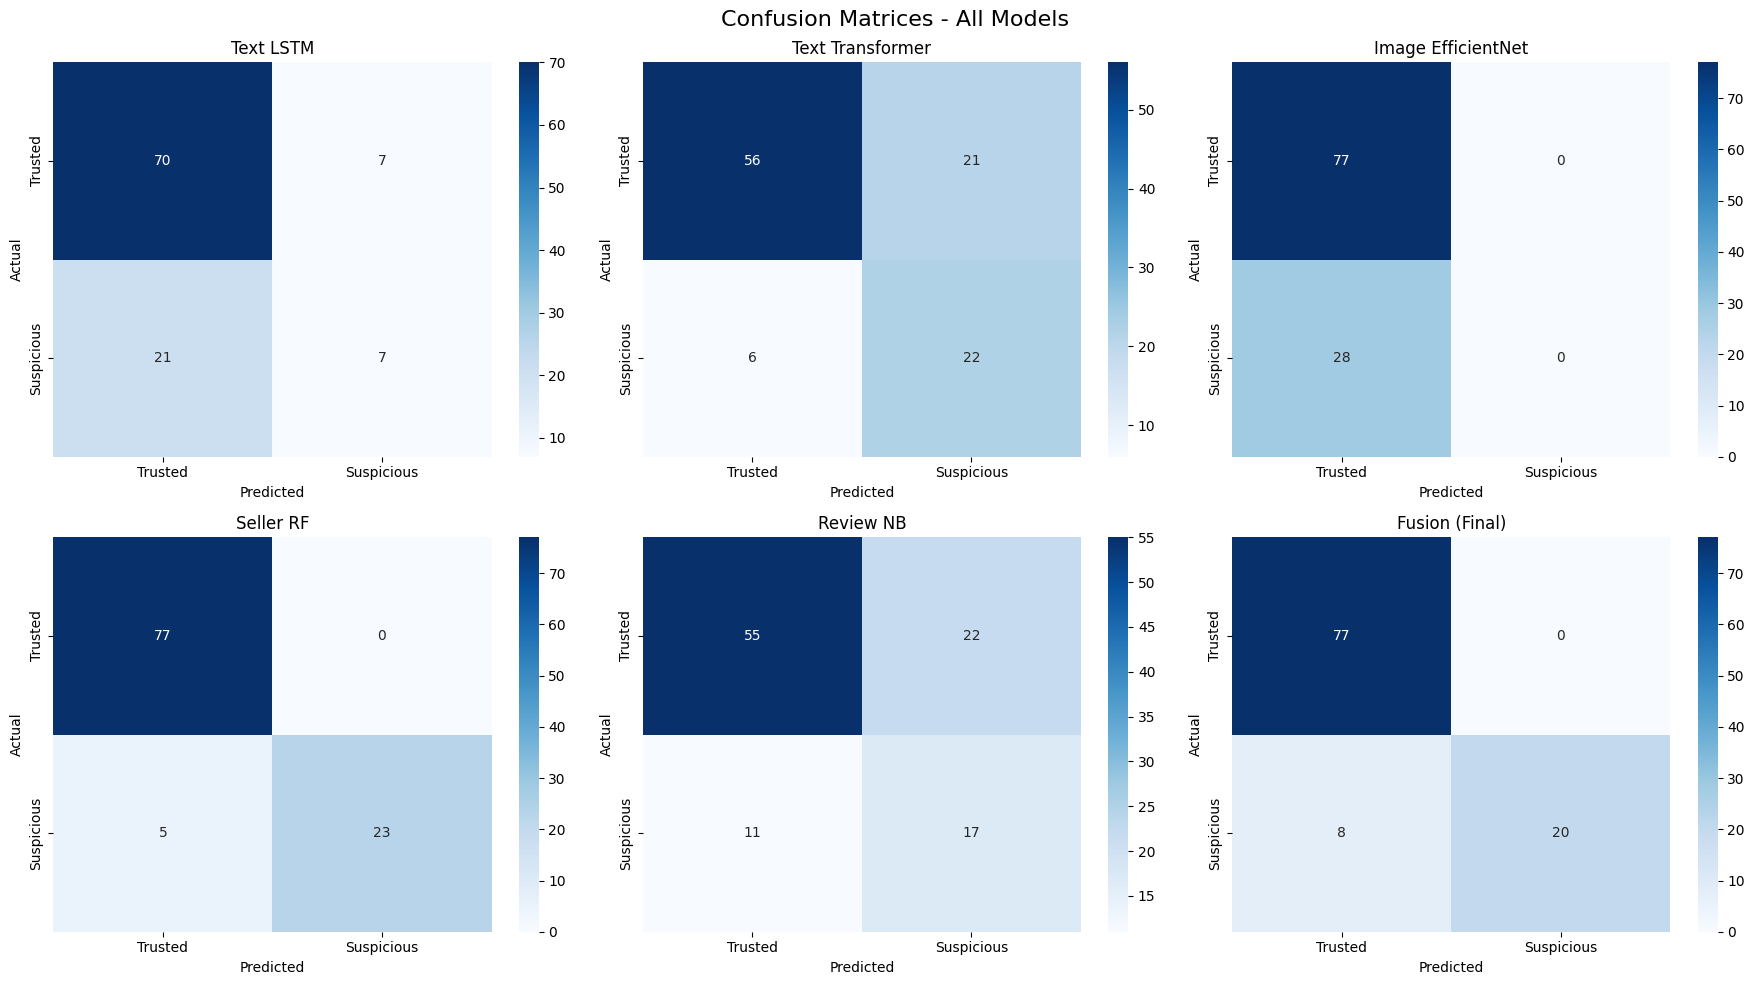

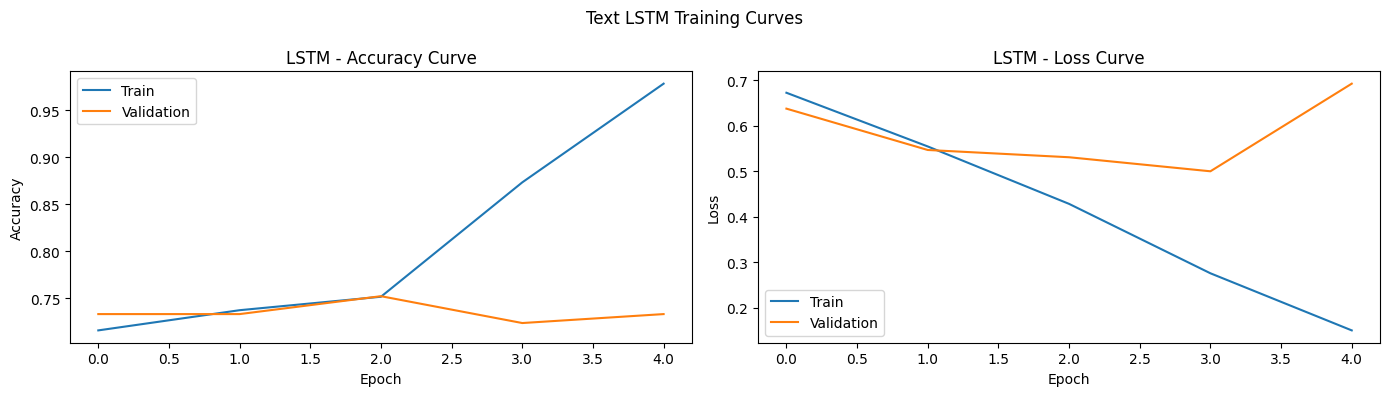

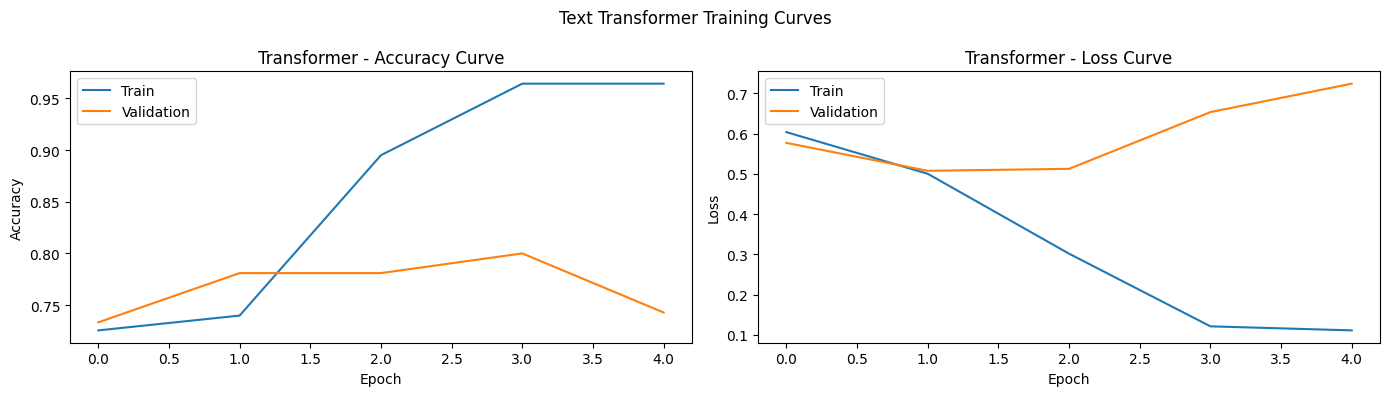

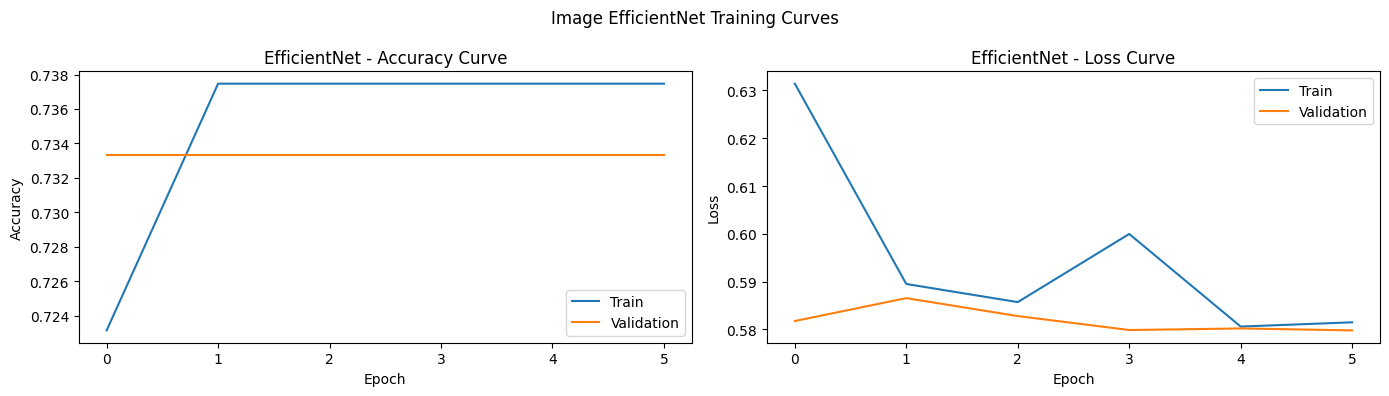

Fusion Model — Full Classification Report
              precision    recall  f1-score   support

     Trusted       0.91      1.00      0.95        77
  Suspicious       1.00      0.71      0.83        28

    accuracy                           0.92       105
   macro avg       0.95      0.86      0.89       105
weighted avg       0.93      0.92      0.92       105



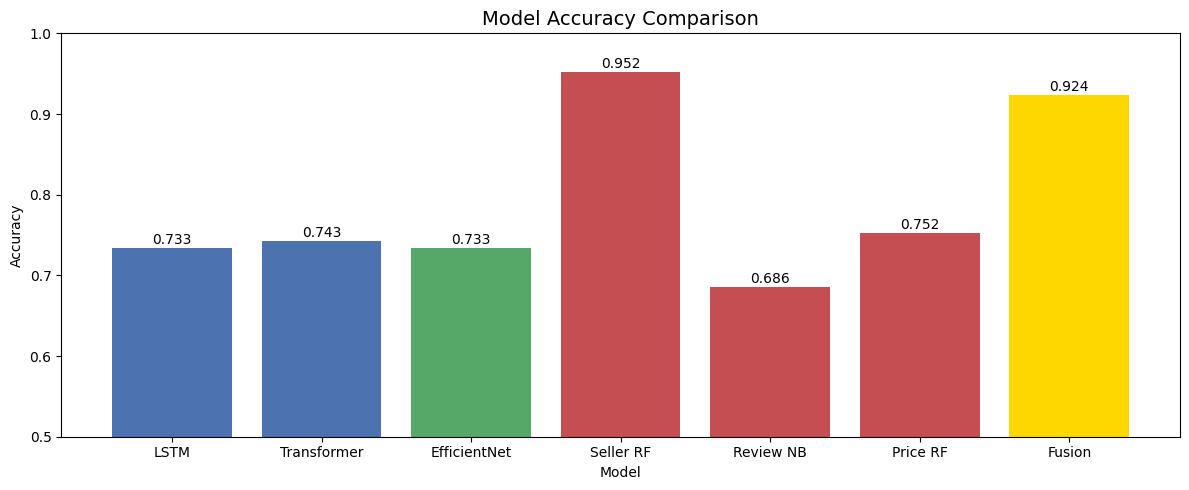

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# 1. Confusion Matrices
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=16)

models_info = [
    (y_test, text_pred, "Text LSTM"),
    (y_test, transformer_pred, "Text Transformer"),
    (y_test, image_pred, "Image EfficientNet"),
    (y_seller_test, seller_pred, "Seller RF"),
    (y_review_test, review_pred, "Review NB"),
    (y_test, fusion_preds, "Fusion (Final)"),
]

for ax, (y_true, y_pred, title) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Trusted', 'Suspicious'],
                yticklabels=['Trusted', 'Suspicious'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


# ============================================================
# 2. Training Curves — LSTM
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_text.history['accuracy'], label='Train')
plt.plot(history_text.history['val_accuracy'], label='Validation')
plt.title('LSTM - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_text.history['loss'], label='Train')
plt.plot(history_text.history['val_loss'], label='Validation')
plt.title('LSTM - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Text LSTM Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 3. Training Curves — Transformer
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transformer.history['accuracy'], label='Train')
plt.plot(history_transformer.history['val_accuracy'], label='Validation')
plt.title('Transformer - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transformer.history['loss'], label='Train')
plt.plot(history_transformer.history['val_loss'], label='Validation')
plt.title('Transformer - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Text Transformer Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 4. Training Curves — Image Model
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_image.history['accuracy'], label='Train')
plt.plot(history_image.history['val_accuracy'], label='Validation')
plt.title('EfficientNet - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_image.history['loss'], label='Train')
plt.plot(history_image.history['val_loss'], label='Validation')
plt.title('EfficientNet - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Image EfficientNet Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 5. Classification Report — Fusion
# ============================================================
print("=" * 50)
print("Fusion Model — Full Classification Report")
print("=" * 50)
print(classification_report(y_test, fusion_preds, target_names=['Trusted', 'Suspicious']))


# ============================================================
# 6. Model Accuracy Bar Chart
# ============================================================
model_names = ["LSTM", "Transformer", "EfficientNet", "Seller RF", "Review NB", "Price RF", "Fusion"]
accuracies = [
    accuracy_score(y_test, text_pred),
    accuracy_score(y_test, transformer_pred),
    accuracy_score(y_test, image_pred),
    accuracy_score(y_seller_test, seller_pred),
    accuracy_score(y_review_test, review_pred),
    accuracy_score(y_price_test, price_pred),
    accuracy_score(y_test, fusion_preds),
]

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, accuracies, color=['#4C72B0','#4C72B0','#55A868','#C44E52','#C44E52','#C44E52','#FFD700'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Model')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

##**Deep Error Analysis**

In [ ]:


from sklearn.metrics import classification_report

# 1. Classification Report
print(classification_report(y_test, fusion_preds, target_names=['Trusted', 'Suspicious']))

# 2. False Positives vs False Negatives
fp_indices = [idx_test[i] for i, (p, t) in enumerate(zip(fusion_preds, y_test)) if p == 1 and t == 0]
fn_indices = [idx_test[i] for i, (p, t) in enumerate(zip(fusion_preds, y_test)) if p == 0 and t == 1]

print(f"\nFalse Positives (predicted Suspicious, actually Trusted): {len(fp_indices)}")
print(f"False Negatives (predicted Trusted, actually Suspicious): {len(fn_indices)}")

# 3. Show examples
print("\n--- False Positive Examples (over-flagged as suspicious) ---")
for i in fp_indices[:3]:
    print(f"  Title: {data.iloc[i]['title'][:60]}")
    print(f"  Seller Rating: {data.iloc[i]['seller_rating']} | Discount: {data.iloc[i]['real_discount']:.1f}%")
    print()

print("--- False Negative Examples (missed suspicious products) ---")
for i in fn_indices[:3]:
    print(f"  Title: {data.iloc[i]['title'][:60]}")
    print(f"  Seller Rating: {data.iloc[i]['seller_rating']} | Discount: {data.iloc[i]['real_discount']:.1f}%")
    print()

# 4. Error pattern analysis
print("Key Insight:")
print(f"  FP Rate: {len(fp_indices)/len(y_test)*100:.1f}% — model is over-cautious")
print(f"  FN Rate: {len(fn_indices)/len(y_test)*100:.1f}% — model misses some suspicious items")
if len(fp_indices) > len(fn_indices):
    print("  → Model biased toward Suspicious: consider lowering threshold below 0.5")
else:
    print("  → Model biased toward Trusted: consider raising threshold above 0.5")

In [ ]:
# ================= SAVE EVERYTHING =================

# Deep Learning models
model_text.save("text_model.h5")
model_text_transformer.save("transformer_model.h5")
model_image.save("image_model.h5")

# Machine learning models
import joblib
joblib.dump(model_seller, "seller_model.pkl")
joblib.dump(model_review, "review_model.pkl")
joblib.dump(model_price, "price_model.pkl")

# Tokenizers
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("review_vectorizer.pkl", "wb") as f:
    pickle.dump(review_vectorizer, f)

In [ ]:
import os
print(os.listdir())

['.config', 'tokenizer.pkl', 'labeled_data.xlsx', 'review_vectorizer.pkl', 'text_model.h5', 'transformer_model.h5', 'drive', 'images', 'seller_model.pkl', 'review_model.pkl', 'price_model.pkl', 'image_model.h5', 'sample_data']


In [ ]:
!zip models.zip *.keras *.pkl *.h5

	zip warning: name not matched: *.keras
  adding: price_model.pkl (deflated 84%)
  adding: review_model.pkl (deflated 79%)
  adding: review_vectorizer.pkl (deflated 71%)
  adding: seller_model.pkl (deflated 84%)
  adding: tokenizer.pkl (deflated 53%)
  adding: image_model.h5 (deflated 11%)
  adding: text_model.h5 (deflated 23%)
  adding: transformer_model.h5 (deflated 24%)
